In [1]:
import sys
import os
import numpy as np
import torch
import PIL.Image
from tqdm import tqdm
import math
import cv2
import matplotlib.pyplot as plt

# Add current directory to path so we can import local modules
sys.path.append(os.getcwd())

# Import your specific modules
from MAT.datasets.mask_generator_256 import RandomMask
import dnnlib
import legacy

# Configuration Paths
IMAGE_PATH = "/home/jincheng/Mural/mural_project/壁画/JPG/临摹品.jpg"
NETWORK_PKL = "/home/jincheng/Mural/mural_project/MAT/outputs/deer_small_hole/network-snapshot-000420.pkl"
OUTPUT_DIR = "restoration_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device('cuda')
print("Environment set up. Device:", device)

/home/jincheng/anaconda3/envs/mural/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment set up. Device: cuda


Original Mural Size: 6674 x 1335


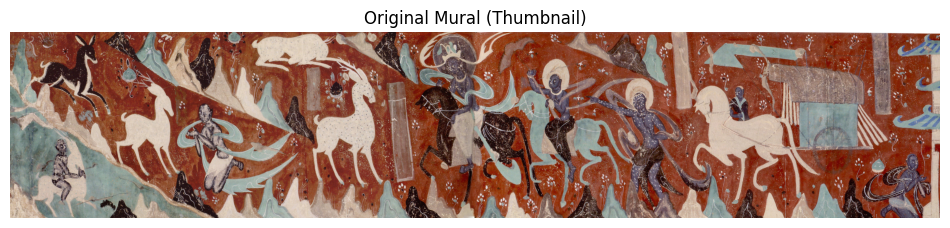

In [2]:
# Load the huge mural
original_pil = PIL.Image.open(IMAGE_PATH).convert('RGB')
W_orig, H_orig = original_pil.size
print(f"Original Mural Size: {W_orig} x {H_orig}")

# Convert to numpy for processing
original_np = np.array(original_pil)

# Display a small thumbnail to verify
plt.figure(figsize=(12, 4))
plt.imshow(original_np)
plt.title("Original Mural (Thumbnail)")
plt.axis('off')
plt.show()

Generating tiled mask... this simulates the training damage.
Damaged image generated.


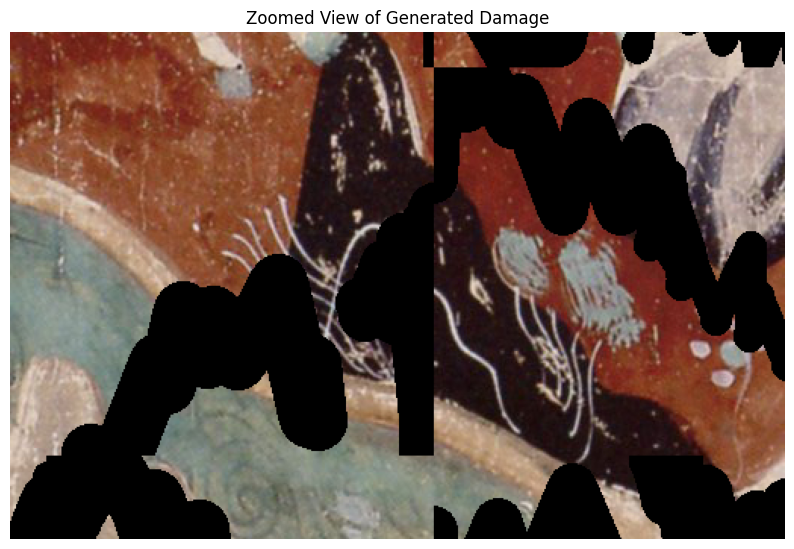

In [3]:
def generate_tiled_mask(full_h, full_w, patch_size=256):
    """
    Generates a mask for a large image by tiling RandomMask
    patches to ensure hole sizes match training distribution.
    """
    # Create an empty canvas for the mask (1 = valid, 0 = hole)
    full_mask = np.ones((full_h, full_w), dtype=np.uint8)

    # Iterate through the image in 256x256 chunks
    for y in range(0, full_h, patch_size):
        for x in range(0, full_w, patch_size):
            # Generate a 256x256 mask (returns shape [1, 256, 256], values 0 or 1)
            # using your specific RandomMask from mask_generator_256.py
            patch_mask = RandomMask(patch_size, hole_range=[0.2, 0.3])
            patch_mask = patch_mask[0] # remove batch dim -> [256, 256]

            # Calculate dimensions for the edge cases (if image isn't divisible by 256)
            h_slice = min(patch_size, full_h - y)
            w_slice = min(patch_size, full_w - x)

            # Crop the generated mask if we are at the edge
            mask_crop = patch_mask[:h_slice, :w_slice]

            # Apply to full mask
            full_mask[y:y+h_slice, x:x+w_slice] = mask_crop

    return full_mask

print("Generating tiled mask... this simulates the training damage.")
large_mask = generate_tiled_mask(H_orig, W_orig)

# Create the visual "Damaged" image (Original * Mask)
# Note: large_mask is 1 for Keep, 0 for Hole.
# We expand dims to broadcast over 3 RGB channels
damaged_np = original_np * large_mask[:, :, np.newaxis]

# Save the damaged version
PIL.Image.fromarray(damaged_np.astype(np.uint8)).save(os.path.join(OUTPUT_DIR, "damaged_mural.png"))
PIL.Image.fromarray((large_mask * 255).astype(np.uint8)).save(os.path.join(OUTPUT_DIR, "mask_full.png"))

print("Damaged image generated.")

# Show a crop of the damage to verify details
plt.figure(figsize=(10, 10))
plt.imshow(damaged_np[1000:1512, 1000:1512]) # View a 512x512 crop
plt.title("Zoomed View of Generated Damage")
plt.axis('off')
plt.show()

In [4]:
# Ensure output directory exists
OUTPUT_DIR = "restoration_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. Save the Damaged Mural (Color image with black holes)
# ---------------------------------------------------------
# We cast to uint8 to ensure it's a valid image format (0-255)
damaged_pil = PIL.Image.fromarray(damaged_np.astype(np.uint8))
damaged_save_path = os.path.join(OUTPUT_DIR, "damaged_mural_full.png")
damaged_pil.save(damaged_save_path)

# ---------------------------------------------------------
# 2. Save the Mask Only (Black and White)
# ---------------------------------------------------------
# large_mask is 0 (hole) and 1 (valid).
# We multiply by 255 so 1 becomes White (255) and 0 remains Black (0).
mask_pil = PIL.Image.fromarray((large_mask * 255).astype(np.uint8))
mask_save_path = os.path.join(OUTPUT_DIR, "mask_full.png")
mask_pil.save(mask_save_path)

print(f"Files saved successfully!")
print(f"Damaged Image: {os.path.abspath(damaged_save_path)}")
print(f"Mask File:     {os.path.abspath(mask_save_path)}")

Files saved successfully!
Damaged Image: /home/jincheng/Mural/mural_project/MAT/restoration_results/damaged_mural_full.png
Mask File:     /home/jincheng/Mural/mural_project/MAT/restoration_results/mask_full.png


In [5]:
print(f"Loading network from: {NETWORK_PKL}")
with dnnlib.util.open_url(NETWORK_PKL) as f:
    network_dict = legacy.load_network_pkl(f)
    G = network_dict['G_ema'].to(device).eval()
print("Model loaded successfully.")

Loading network from: /home/jincheng/Mural/mural_project/MAT/outputs/deer_small_hole/network-snapshot-000420.pkl
Model loaded successfully.


In [6]:
import torch.nn.functional as F

def get_gaussian_kernel(size, sigma=None):
    """
    Generates a 2D Gaussian kernel.
    This creates a 'hill' shape: high in the middle, low at the edges.
    """
    if sigma is None:
        sigma = size * 0.3
    x = np.linspace(-1, 1, size)
    x, y = np.meshgrid(x, x)
    d = np.sqrt(x*x + y*y)
    g = np.exp(-( (d)**2 / (2.0 * sigma**2) ))
    return torch.from_numpy(g).float()

def restore_large_image(img_np, mask_np, net, tile_size=256, overlap_percent=0.5):
    """
    Restores a large image using sliding windows with Gaussian blending.
    Corrected to handle PyTorch padding dimensions properly.
    """
    print(f"Starting restoration on image of size {img_np.shape}...")

    # 1. Setup Data
    # Convert image to Tensor and ADD BATCH DIMENSION: (1, 3, H, W)
    img_t = torch.from_numpy(img_np).float().permute(2, 0, 1).unsqueeze(0) / 127.5 - 1

    # Convert mask to Tensor and ADD BATCH DIMENSION: (1, 1, H, W)
    # mask_np is (H, W), so unsqueeze(0) -> (1, H, W), unsqueeze(0) -> (1, 1, H, W)
    mask_t = torch.from_numpy(mask_np).float().unsqueeze(0).unsqueeze(0)

    # 2. Padding
    H, W = img_np.shape[:2]
    stride = int(tile_size * (1 - overlap_percent))

    pad_h = (math.ceil(H / stride) * stride) + tile_size - H
    pad_w = (math.ceil(W / stride) * stride) + tile_size - W

    # Now F.pad receives 4D tensors, so it accepts 4 padding values (left, right, top, bottom)
    img_padded = F.pad(img_t, (0, pad_w, 0, pad_h), mode='reflect')
    mask_padded = F.pad(mask_t, (0, pad_w, 0, pad_h), value=0)

    # REMOVE BATCH DIMENSION to return to 3D: (3, H_pad, W_pad) and (1, H_pad, W_pad)
    # This ensures the loop logic below (which expects 3D inputs) remains valid
    img_padded = img_padded.squeeze(0)
    mask_padded = mask_padded.squeeze(0)

    _, H_pad, W_pad = img_padded.shape

    # 3. Create Accumulation Buffers (on GPU)
    output_canvas = torch.zeros(3, H_pad, W_pad).to(device)
    weight_map = torch.zeros(1, H_pad, W_pad).to(device)

    # Create the Gaussian weight for a single tile
    tile_weight = get_gaussian_kernel(tile_size).to(device)

    # Fixed noise vector z
    z = torch.randn([1, net.z_dim], device=device)

    # 4. Sliding Window Loop
    y_steps = list(range(0, H_pad - tile_size + 1, stride))
    x_steps = list(range(0, W_pad - tile_size + 1, stride))
    total_steps = len(y_steps) * len(x_steps)

    print(f"Processing {total_steps} tiles (Tile Size: {tile_size}, Stride: {stride})...")
    pbar = tqdm(total=total_steps)

    for y in y_steps:
        for x in x_steps:
            # Extract Crop (move to GPU)
            # Input is 3D, so we slice [:, y:y+h, x:x+w] and then unsqueeze to make it 4D for the model
            img_crop = img_padded[:, y:y+tile_size, x:x+tile_size].unsqueeze(0).to(device)
            mask_crop = mask_padded[:, y:y+tile_size, x:x+tile_size].unsqueeze(0).to(device)

            with torch.no_grad():
                # Inference
                restored_crop = net(img_crop, mask_crop, z, c=None, noise_mode='const')

                # Take the result
                pred = restored_crop[0]

                # Accumulate
                output_canvas[:, y:y+tile_size, x:x+tile_size] += pred * tile_weight
                weight_map[:, y:y+tile_size, x:x+tile_size] += tile_weight

            pbar.update(1)

    pbar.close()

    # 5. Normalize and Finish
    output_canvas = output_canvas / (weight_map + 1e-8)
    restored_img = output_canvas[:, :H, :W]
    restored_img = (restored_img.clamp(-1, 1) + 1) * 127.5
    restored_img = restored_img.permute(1, 2, 0).cpu().numpy().astype(np.uint8)

    return restored_img

# --- EXECUTE THE RESTORATION ---
# Note: large_mask and damaged_np were created in Step 3
# Ensure overlap is 0.5 (50%) for best quality
restored_mural = restore_large_image(
    damaged_np,      # The 'damaged' input image
    large_mask,      # The mask (0=hole, 1=valid)
    G,               # The loaded generator
    tile_size=256,
    overlap_percent=0.5
)

print("Restoration finished.")

Starting restoration on image of size (1335, 6674, 3)...
Processing 648 tiles (Tile Size: 256, Stride: 128)...


  0%|          | 0/648 [00:00<?, ?it/s]

Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... 

  0%|          | 1/648 [00:01<18:21,  1.70s/it]

Done.


100%|██████████| 648/648 [01:30<00:00,  7.15it/s]


Restoration finished.


Restoration complete. Saved to restoration_results/restored_mural_final.png


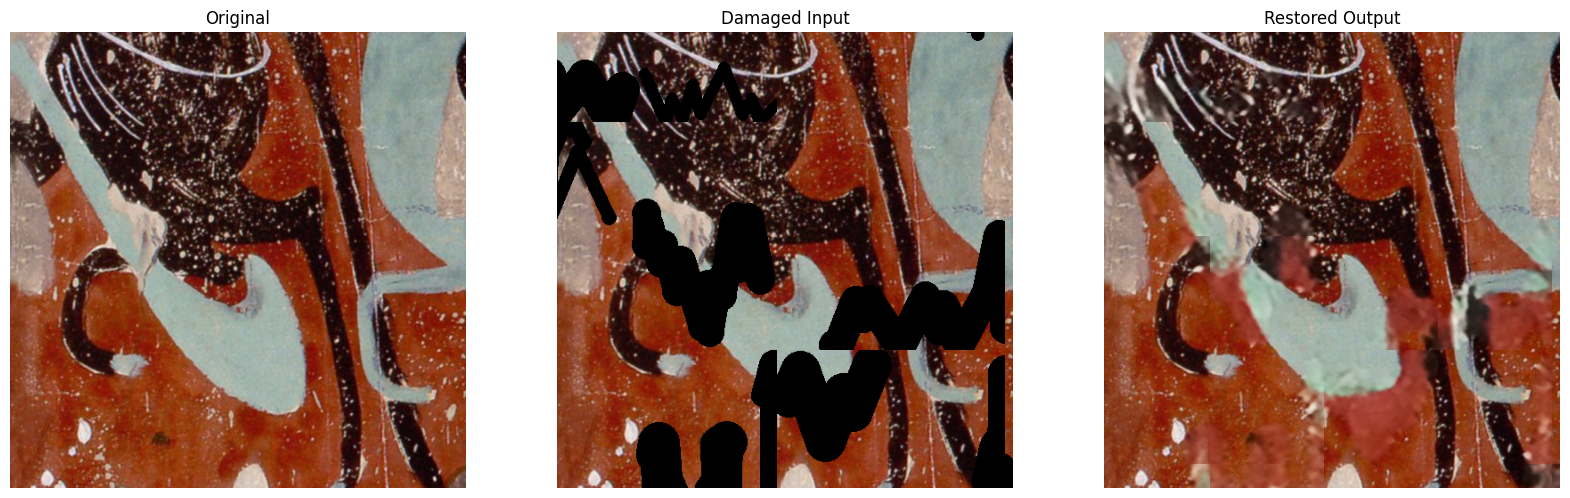

In [7]:
# Save Full Result
save_path = os.path.join(OUTPUT_DIR, "restored_mural_final.png")
PIL.Image.fromarray(restored_mural).save(save_path)
print(f"Restoration complete. Saved to {save_path}")

# Visualization Comparison (Zoom in on a specific area)
# Let's pick a center crop to see details
cy, cx = H_orig // 2, W_orig // 2
crop_s = 512

orig_c = original_np[cy:cy+crop_s, cx:cx+crop_s]
dmg_c = damaged_np[cy:cy+crop_s, cx:cx+crop_s]
rest_c = restored_mural[cy:cy+crop_s, cx:cx+crop_s]

fig, ax = plt.subplots(1, 3, figsize=(20, 8))
ax[0].imshow(orig_c)
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(dmg_c)
ax[1].set_title("Damaged Input")
ax[1].axis('off')

ax[2].imshow(rest_c)
ax[2].set_title("Restored Output")
ax[2].axis('off')

plt.show()